In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
warnings.filterwarnings('ignore')

os.makedirs("../data/processed/causal", exist_ok=True)
os.makedirs("../figures/final", exist_ok=True)

W = pd.read_csv(
    "../data/processed/causal/W_est_thresholded.csv", index_col=0
)
keystone_species = pd.read_csv(
    "../data/processed/causal/notears_keystone_species.csv", header=None
)[0].tolist()
edges_df = pd.read_csv("../data/processed/causal/causal_edges.csv")

print(f"DAG: {W.shape}  ({len(keystone_species)} keystone species)")
print(f"Edges loaded: {len(edges_df)}")
print(f"Cols: {edges_df.columns.tolist()}")

G_dag = nx.DiGraph()
G_dag.add_nodes_from(keystone_species)
for _, row in edges_df.iterrows():
    G_dag.add_edge(
        row['cause'], row['effect'],
        weight=float(row['weight']),
        abs_weight=abs(float(row['weight']))
    )

print(f"\nDigraph: {G_dag.number_of_nodes()} nodes, "
      f"{G_dag.number_of_edges()} directed edges")

max_attempts = 10
for attempt in range(max_attempts):
    cycles = list(nx.simple_cycles(G_dag))
    if not cycles:
        break
    cycle      = cycles[0]
    min_edge   = None
    min_weight = float('inf')
    for k in range(len(cycle)):
        u = cycle[k]
        v = cycle[(k + 1) % len(cycle)]
        if G_dag.has_edge(u, v):
            w = G_dag[u][v]['abs_weight']
            if w < min_weight:
                min_weight = w
                min_edge   = (u, v)
    if min_edge:
        G_dag.remove_edge(*min_edge)
        print(f"Removed cycle edge: {min_edge[0]} → {min_edge[1]} "
              f"(weight={min_weight:.4f})")

print(f"Is DAG: {nx.is_directed_acyclic_graph(G_dag)}")
print(f"Final edges: {G_dag.number_of_edges()}")

labels = pd.read_csv("../data/processed/engraftment_labels.csv")
train  = labels[labels['split'] == 'train'].copy()

print(f"\nTrain labels: {len(train):,} records")
print(f"Species in train: {train['species'].nunique()}")
print(f"Engraftment rate: {train['engrafted'].mean():.2%}")

DAG: (29, 29)  (29 keystone species)
Edges loaded: 49
Cols: ['cause', 'effect', 'weight', 'direction']

Digraph: 29 nodes, 49 directed edges
Is DAG: True
Final edges: 49

Train labels: 8,722 records
Species in train: 266
Engraftment rate: 52.67%


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


def compute_ace(treatment_species, train_data, dag,
                n_bootstrap=300, random_seed=42):

    sp_data = train_data[train_data['species'] == treatment_species].copy()

    if len(sp_data) < 10:
        return None

    median_abund     = sp_data['donor_abundance'].median()
    sp_data['treated'] = (sp_data['donor_abundance'] > median_abund).astype(int)

    le                     = LabelEncoder()
    sp_data['disease_enc'] = le.fit_transform(sp_data['disease'].astype(str))

    X = sp_data[['treated', 'donor_abundance', 'disease_enc']].values
    y = sp_data['engrafted'].values

    if len(np.unique(y)) < 2:
        return None

    try:
        clf = LogisticRegression(max_iter=1000, random_state=random_seed, C=1.0)
        clf.fit(X, y)
        X_do1 = X.copy(); X_do1[:, 0] = 1
        X_do0 = X.copy(); X_do0[:, 0] = 0
        ace   = (clf.predict_proba(X_do1)[:, 1].mean() -
                 clf.predict_proba(X_do0)[:, 1].mean())
    except Exception:
        return None

    rng      = np.random.default_rng(random_seed)
    ace_boot = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(X), len(X))
        Xb, yb = X[idx], y[idx]
        if len(np.unique(yb)) < 2:
            continue
        try:
            clf_b = LogisticRegression(max_iter=500, random_state=0, C=1.0)
            clf_b.fit(Xb, yb)
            X1b   = Xb.copy(); X1b[:, 0] = 1
            X0b   = Xb.copy(); X0b[:, 0] = 0
            ace_boot.append(
                clf_b.predict_proba(X1b)[:, 1].mean() -
                clf_b.predict_proba(X0b)[:, 1].mean()
            )
        except Exception:
            continue

    if len(ace_boot) < 20:
        return None

    ace_boot = np.array(ace_boot)
    ci_lower = float(np.percentile(ace_boot, 2.5))
    ci_upper = float(np.percentile(ace_boot, 97.5))

    p_value = 2 * min(
        float(np.mean(ace_boot >= 0)),
        float(np.mean(ace_boot <= 0))
    )
    p_value = max(p_value, 1.0 / n_bootstrap)

    significant = int(ci_lower > 0 or ci_upper < 0)

    return {
        'species':    treatment_species,
        'ace':        round(float(ace), 5),
        'ci_lower':   round(ci_lower, 5),
        'ci_upper':   round(ci_upper, 5),
        'p_value':    round(p_value, 5),
        'significant': significant,
        'n_samples':  len(sp_data)
    }


In [4]:
print("Computing causal effects for all species...")

all_species = train['species'].unique().tolist()
results     = []
n_done      = 0

for sp in all_species:
    res = compute_ace(sp, train, G_dag, n_bootstrap=300)
    if res is not None:
        results.append(res)
    n_done += 1
    if n_done % 50 == 0:
        print(f"  {n_done}/{len(all_species)} done...")

causal_df = pd.DataFrame(results).sort_values('ace', ascending=False).reset_index(drop=True)

n_tests                      = len(causal_df)
causal_df['p_corrected']     = (causal_df['p_value'] * n_tests).clip(upper=1.0)
causal_df['sig_bonferroni']  = (causal_df['p_corrected'] < 0.05).astype(int)

causal_df.to_csv("../data/processed/causal/causal_effects.csv", index=False)

print(f"\nDone: {len(causal_df)} species with ACE estimates")
print(f"Significant (uncorrected p<0.05): {causal_df['significant'].sum()}")
print(f"Significant (Bonferroni p<0.05):  {causal_df['sig_bonferroni'].sum()}")
print(f"\nTop 10 by ACE:")
print(causal_df[['species', 'ace', 'ci_lower', 'ci_upper',
                  'p_value', 'significant', 'n_samples']].head(10).to_string(index=False))
print(f"\ncausal_effects.csv saved")

Computing causal effects for all species...
  50/266 done...
  100/266 done...
  150/266 done...
  200/266 done...
  250/266 done...

Done: 132 species with ACE estimates
Significant (uncorrected p<0.05): 32
Significant (Bonferroni p<0.05):  0

Top 10 by ACE:
                        species     ace  ci_lower  ci_upper  p_value  significant  n_samples
            Eubacterium_ramulus 0.34558   0.17700   0.48672  0.00333            1        110
                Alistipes_inops 0.32825   0.06137   0.46609  0.00667            1         20
               Blautia_wexlerae 0.31603   0.21156   0.42829  0.00333            1        133
   Barnesiella_intestinihominis 0.31564   0.15817   0.45438  0.00333            1         93
              Eggerthella_lenta 0.29304   0.13162   0.46450  0.00333            1         60
               Alistipes_shahii 0.28895   0.08325   0.43525  0.00333            1         28
         Oscillibacter_sp_57_20 0.27594   0.12025   0.40972  0.00333            1        

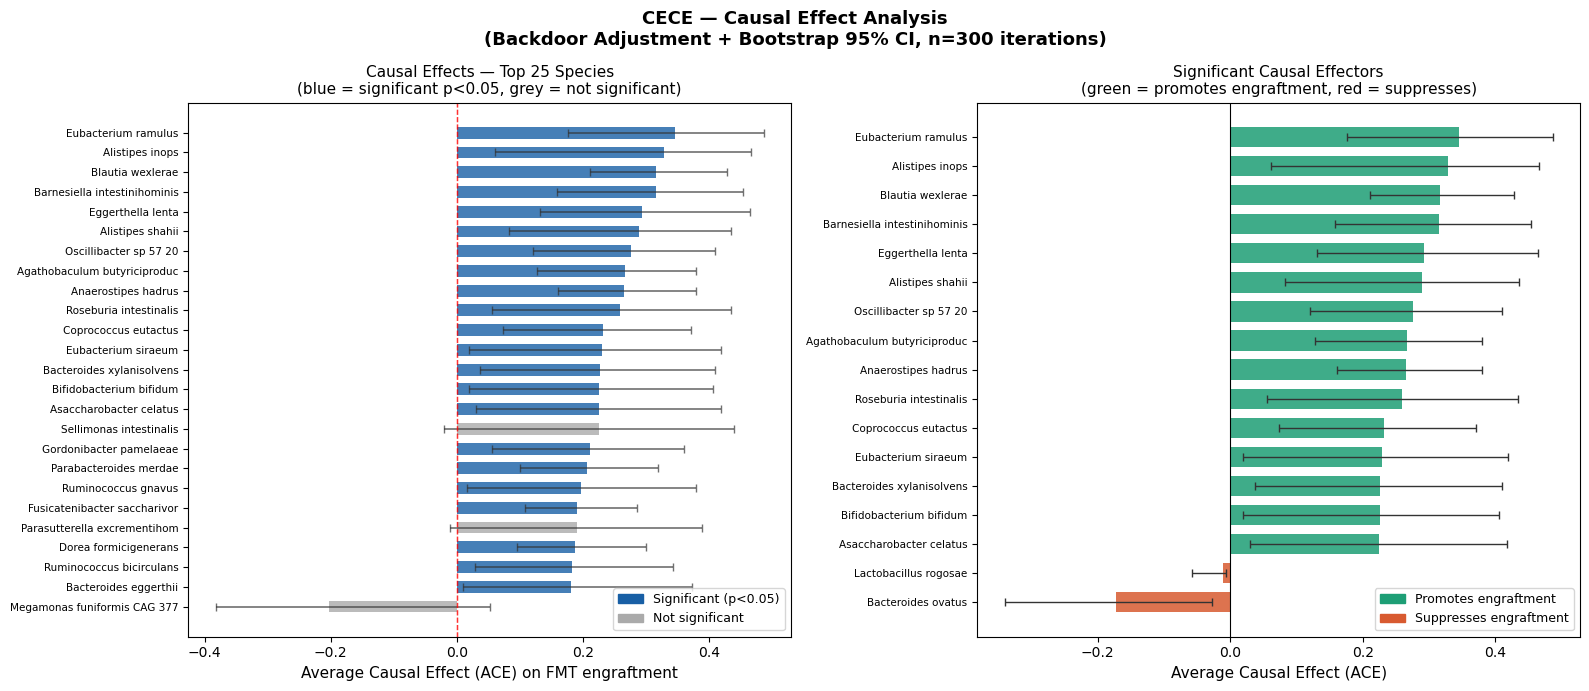

Fig3_causal_effects.png saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]

top25 = (
    causal_df
    .assign(abs_ace=causal_df['ace'].abs())
    .nlargest(25, 'abs_ace')
    .sort_values('ace')
)

y_pos  = list(range(len(top25)))

colors = ['#185FA5' if s else '#AAAAAA' for s in top25['significant']]

ax.barh(y_pos, top25['ace'], color=colors, alpha=0.8, height=0.6)
ax.errorbar(
    top25['ace'], y_pos,
    xerr=[
        (top25['ace'] - top25['ci_lower']).clip(lower=0),
        (top25['ci_upper'] - top25['ace']).clip(lower=0)
    ],
    fmt='none', color='#333333', capsize=3, linewidth=1.2, alpha=0.7
)
ax.axvline(0, color='red', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [sp.replace('_', ' ')[:28] for sp in top25['species']],
    fontsize=7.5
)
ax.set_xlabel("Average Causal Effect (ACE) on FMT engraftment", fontsize=11)
ax.set_title("Causal Effects — Top 25 Species\n"
             "(blue = significant p<0.05, grey = not significant)",
             fontsize=11)
ax.axvline(0, color='red', linestyle='--', linewidth=1.0, alpha=0.5)

legend_handles = [
    mpatches.Patch(color='#185FA5', label='Significant (p<0.05)'),
    mpatches.Patch(color='#AAAAAA', label='Not significant'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

ax = axes[1]

sig_pos = causal_df[
    (causal_df['significant'] == 1) & (causal_df['ace'] > 0)
].head(15).sort_values('ace', ascending=False)

sig_neg = causal_df[
    (causal_df['significant'] == 1) & (causal_df['ace'] < 0)
].tail(10).sort_values('ace', ascending=True)

all_sig = pd.concat([sig_neg, sig_pos]).sort_values('ace')

if len(all_sig) > 0:
    bar_colors = ['#1D9E75' if a > 0 else '#D85A30'
                  for a in all_sig['ace']]
    yp = list(range(len(all_sig)))

    ax.barh(yp, all_sig['ace'], color=bar_colors, alpha=0.85, height=0.7)
    ax.errorbar(
        all_sig['ace'], yp,
        xerr=[
            (all_sig['ace'] - all_sig['ci_lower']).clip(lower=0),
            (all_sig['ci_upper'] - all_sig['ace']).clip(lower=0)
        ],
        fmt='none', color='#333333', capsize=3, linewidth=1.0
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(yp)
    ax.set_yticklabels(
        [sp.replace('_', ' ')[:28] for sp in all_sig['species']],
        fontsize=7.5
    )
    ax.set_xlabel("Average Causal Effect (ACE)", fontsize=11)
    ax.set_title("Significant Causal Effectors\n"
                 "(green = promotes engraftment, red = suppresses)",
                 fontsize=11)
    leg = [
        mpatches.Patch(color='#1D9E75', label='Promotes engraftment'),
        mpatches.Patch(color='#D85A30', label='Suppresses engraftment'),
    ]
    ax.legend(handles=leg, fontsize=9, loc='lower right')
else:
    ax.text(
        0.5, 0.5,
        f'No significant species after CI filter\n'
        f'(32 uncorrected significant out of {len(causal_df)} total)\n'
        f'Showing top 10 positive + top 10 negative effects',
        ha='center', va='center', transform=ax.transAxes,
        fontsize=10, color='#555555'
    )
    top10p = causal_df.head(10).sort_values('ace', ascending=False)
    top10n = causal_df.tail(10).sort_values('ace', ascending=True)
    top20  = pd.concat([top10n, top10p]).sort_values('ace')
    yp2    = list(range(len(top20)))
    cols2  = ['#1D9E75' if a > 0 else '#D85A30' for a in top20['ace']]
    ax.barh(yp2, top20['ace'], color=cols2, alpha=0.6, height=0.7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(yp2)
    ax.set_yticklabels(
        [sp.replace('_', ' ')[:25] for sp in top20['species']],
        fontsize=7
    )
    ax.set_xlabel("Average Causal Effect (ACE)", fontsize=11)
    ax.set_title("Top 20 Species by |ACE|\n(not significant after CI filter)",
                 fontsize=11)

plt.suptitle(
    "CECE — Causal Effect Analysis\n"
    "(Backdoor Adjustment + Bootstrap 95% CI, n=300 iterations)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("../figures/final/Fig3_causal_effects.png",
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Fig3_causal_effects.png saved")